<a href="https://colab.research.google.com/github/manavsharma111/Machine-Learning/blob/main/stacking_Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
# import sheryanalysis as sys
warnings.filterwarnings('ignore')

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
# import sklearn.svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [36]:
df = pd.read_csv('Iris.csv')

In [37]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [38]:
X=df.drop(['Species', 'Id'], axis=1)
y=df['Species']

In [80]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.5,random_state=1)

In [49]:
from sklearn.preprocessing import LabelEncoder

In [84]:
base_learnes = [
    ('knn', KNeighborsClassifier(n_neighbors=50, weights='uniform', metric='manhattan')),
    ('lr', LogisticRegression(max_iter=2)),
    ('svm', SVC(probability=True, kernel='linear', C=0.1)),
    ('dt', DecisionTreeClassifier(max_depth=2))
]

In [85]:
meta_learner = LogisticRegression(max_iter=2)

In [94]:
stacking_clf = StackingClassifier(
    estimators=base_learnes,
    final_estimator=meta_learner,
    cv=5
    )

In [95]:
stacking_clf.fit(X_train, Y_train)

StackingClassifier(cv=5,
                   estimators=[('knn',
                                KNeighborsClassifier(metric='manhattan',
                                                     n_neighbors=50)),
                               ('lr', LogisticRegression(max_iter=2)),
                               ('svm',
                                SVC(C=0.1, kernel='linear', probability=True)),
                               ('dt', DecisionTreeClassifier(max_depth=2))],
                   final_estimator=LogisticRegression(max_iter=2))

In [82]:
Y_pred = stacking_clf.predict(X_test)

In [83]:
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


In [87]:
from sklearn.ensemble import RandomForestClassifier

In [88]:
rf_model=RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42

)

In [89]:
rf_model.fit(X_train, Y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [90]:
Y_pred = rf_model.predict(X_test)

In [91]:
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9466666666666667


In [92]:
confusion_matrix = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[24  0  0]
 [ 0 23  1]
 [ 0  3 24]]


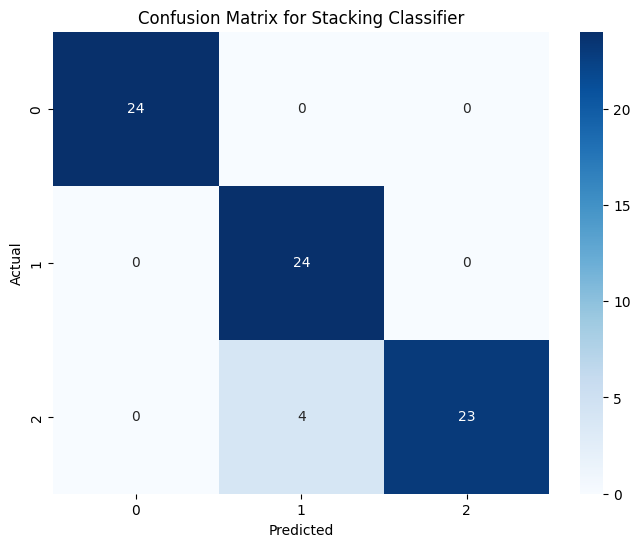

In [96]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from the stacking classifier
Y_pred_stacking = stacking_clf.predict(X_test)

# Calculate the confusion matrix for the stacking classifier
cm_stacking = confusion_matrix(Y_test, Y_pred_stacking)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_stacking, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Stacking Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [97]:
from sklearn.metrics import classification_report

# Classification report for Random Forest
print("Classification Report for Random Forest Model:")
print(classification_report(Y_test, Y_pred))

Classification Report for Random Forest Model:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        24
Iris-versicolor       0.88      0.96      0.92        24
 Iris-virginica       0.96      0.89      0.92        27

       accuracy                           0.95        75
      macro avg       0.95      0.95      0.95        75
   weighted avg       0.95      0.95      0.95        75



In [103]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, Y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy found: ", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found:  {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Best accuracy found:  0.9600000000000002


In [100]:
from sklearn.metrics import classification_report

# Get predictions from the stacking classifier
Y_pred_stacking = stacking_clf.predict(X_test)

# Classification report for Stacking Classifier
print("Classification Report for Stacking Classifier Model:")
print(classification_report(Y_test, Y_pred_stacking))

Classification Report for Stacking Classifier Model:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        24
Iris-versicolor       0.86      1.00      0.92        24
 Iris-virginica       1.00      0.85      0.92        27

       accuracy                           0.95        75
      macro avg       0.95      0.95      0.95        75
   weighted avg       0.95      0.95      0.95        75



In [101]:
from sklearn.metrics import classification_report

# Get predictions from the stacking classifier
Y_pred_stacking = stacking_clf.predict(X_test)

# Classification report for Stacking Classifier
print("Classification Report for Stacking Classifier Model:")
print(classification_report(Y_test, Y_pred_stacking))

Classification Report for Stacking Classifier Model:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        24
Iris-versicolor       0.86      1.00      0.92        24
 Iris-virginica       1.00      0.85      0.92        27

       accuracy                           0.95        75
      macro avg       0.95      0.95      0.95        75
   weighted avg       0.95      0.95      0.95        75



In [102]:
from sklearn.metrics import classification_report

# Get predictions from the stacking classifier
Y_pred_stacking = stacking_clf.predict(X_test)

# Classification report for Stacking Classifier
print("Classification Report for Stacking Classifier Model:")
print(classification_report(Y_test, Y_pred_stacking))

Classification Report for Stacking Classifier Model:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        24
Iris-versicolor       0.86      1.00      0.92        24
 Iris-virginica       1.00      0.85      0.92        27

       accuracy                           0.95        75
      macro avg       0.95      0.95      0.95        75
   weighted avg       0.95      0.95      0.95        75



In [98]:
from sklearn.metrics import classification_report

# Classification report for Random Forest
print("Classification Report for Random Forest Model:")
print(classification_report(Y_test, Y_pred))

Classification Report for Random Forest Model:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        24
Iris-versicolor       0.88      0.96      0.92        24
 Iris-virginica       0.96      0.89      0.92        27

       accuracy                           0.95        75
      macro avg       0.95      0.95      0.95        75
   weighted avg       0.95      0.95      0.95        75



In [99]:
from sklearn.metrics import classification_report

# Classification report for Random Forest
print("Classification Report for Random Forest Model:")
print(classification_report(Y_test, Y_pred))

Classification Report for Random Forest Model:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        24
Iris-versicolor       0.88      0.96      0.92        24
 Iris-virginica       0.96      0.89      0.92        27

       accuracy                           0.95        75
      macro avg       0.95      0.95      0.95        75
   weighted avg       0.95      0.95      0.95        75

